# Milestone 4 Final Classification

This notebook tests whether outdoor dining locations that remained active can be classified from locations that disappeared.

This is not a causal model. It does not explain why each restaurant stayed or disappeared. It only tests whether the two groups are distinguishable using the available features.

## Research Question

Can a Random Forest classifier distinguish remained outdoor dining locations from disappeared locations?

## Target Variable

The target variable is `survived`.

`survived = 1` means the location is still active in the current Dining Out NYC dataset.

`survived = 0` means the location appeared in the historic emergency program but is no longer active.

## Feature Groups

I tested two feature groups.

Local context:
`dist_subway_m`, `is_near_transit`, `streetwidth`, `streetwidth_missing`

Spatial repetition:
`is_corridor`, `same_street_nearby_count_1000ft`, `nearby_outdoor_dining_count_300ft`

I tested them separately, then together.

In [28]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py

In [29]:
import json
import math
import statistics
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from scipy.spatial import cKDTree

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

## 1. Load and Clean Raw Data

### 1a. Historic locations

Source: `Open_Restaurant_Applications_(Historic)_20260307.csv`

I loaded the historic emergency outdoor dining dataset, filtered it to Manhattan, removed invalid coordinates, and deduplicated locations by rounded latitude and longitude.

In [30]:
historic_raw_df = pd.read_csv('data/Open_Restaurant_Applications_(Historic)_20260307.csv')

print(f'Raw historic: {len(historic_raw_df):,} rows')
print(f'Boroughs: {historic_raw_df["Borough"].value_counts().to_dict()}')
print(f'Columns: {list(historic_raw_df.columns[:6])}...')

historic_raw_df.head(3)

Raw historic: 14,428 rows
Boroughs: {'Manhattan': 7179, 'Brooklyn': 3548, 'Queens': 2751, 'Bronx': 747, 'Staten Island': 203}
Columns: ['objectid', 'globalid', 'Seating Interest (Sidewalk/Roadway/Both)', 'Restaurant Name', 'Legal Business Name', 'Doing Business As (DBA)']...


,objectid,globalid,Seating Interest (Sidewalk/Roadway/Both),Restaurant Name,Legal Business Name,Doing Business As (DBA),Building Number,Street,Borough,Postcode,...,healthCompliance_terms,Time of Submission,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA
0,100,c4b3155b-31a0-4e95-846f-fce09f245437,sidewalk,Pomp and Circumstance Hospitality,Pomp and Circumstance Hospitality LLC,Pomp and Circumstance Hospitality LLC,577,Lorimer Street,Brooklyn,11211,...,yes,06/19/2020 11:04:00 AM,40.714264,-73.949416,1.0,34.0,501.0,3068653.0,3.027560e+09,East Williamsburg
1,1000,753495d8-4429-43e5-85a3-dcf6230ef749,both,Charm Kao,193 Schemerhorn INC,Charm Kao,193,Schermerhorn St.,Brooklyn,11201,...,yes,06/19/2020 02:35:00 PM,40.689107,-73.986352,2.0,33.0,37.0,3000493.0,3.001640e+09,DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hill
2,10000,{3842B5C5-EF04-41A4-8216-D6EA627DCE5E},openstreets,SAKE BAR HAGI 46,"HAMA NEW YORK, INC.",SAKE BAR HAGI 46,358,W. 46TH STREET,Manhattan,10036,...,yes,08/07/2020 01:28:00 PM,40.760463,-73.989528,4.0,3.0,121.0,1025025.0,1.010360e+09,Clinton


In [31]:
hist_manh_df = historic_raw_df[
    (historic_raw_df['Borough'] == 'Manhattan') &
    (historic_raw_df['Latitude'].notna()) &
    (historic_raw_df['Longitude'].notna()) &
    (historic_raw_df['Latitude'].astype(float) > 40.68) &
    (historic_raw_df['Latitude'].astype(float) < 40.88) &
    (historic_raw_df['Longitude'].astype(float) > -74.03) &
    (historic_raw_df['Longitude'].astype(float) < -73.90)
].copy()

print(f'Manhattan with coords: {len(hist_manh_df):,}')

hist_manh_df['lat_r'] = hist_manh_df['Latitude'].round(5)
hist_manh_df['lon_r'] = hist_manh_df['Longitude'].round(5)

before_dedup = len(hist_manh_df)
hist_manh_df = hist_manh_df.drop_duplicates(subset=['lat_r', 'lon_r'])

print(f'After coordinate deduplication: {len(hist_manh_df):,}')
print(f'Removed as duplicates: {before_dedup - len(hist_manh_df):,}')

Manhattan with coords: 6,467
After coordinate deduplication: 4,659
Removed as duplicates: 1,808


In [32]:
print('Missing values in key historic columns:')
print(hist_manh_df[['Latitude', 'Longitude', 'Street', 'Seating Interest (Sidewalk/Roadway/Both)']].isnull().sum())

print('\nSeating interest:')
print(hist_manh_df['Seating Interest (Sidewalk/Roadway/Both)'].value_counts())

Missing values in key historic columns:
Latitude                                    0
Longitude                                   0
Street                                      0
Seating Interest (Sidewalk/Roadway/Both)    0
dtype: int64

Seating interest:
Seating Interest (Sidewalk/Roadway/Both)
both           2295
sidewalk       1605
roadway         698
openstreets      61
Name: count, dtype: int64


In [33]:
hist_clean_df = hist_manh_df[['lat_r', 'lon_r', 'Street']].copy()
hist_clean_df.columns = ['lat', 'lon', 'street_name']
hist_clean_df['survived'] = 0
hist_clean_df['street_name'] = hist_clean_df['street_name'].fillna('').str.upper().str.strip()

print(f'Historic clean: {len(hist_clean_df):,} rows')

hist_clean_df.head(3)

Historic clean: 4,659 rows


,lat,lon,street_name,survived
2,40.76046,-73.98953,W. 46TH STREET,0
3,40.76108,-73.99068,9AVE,0
5,40.70402,-74.01020,PEARL STREET,0


### 1b. Current locations

Source: `Dining_Out_NYC_Locations.csv`

I loaded the current Dining Out NYC dataset, filtered it to Manhattan, and deduplicated locations by rounded latitude and longitude.

In [34]:
current_raw_df = pd.read_csv('data/Dining_Out_NYC_Locations.csv')

print(f'Raw current: {len(current_raw_df):,} rows')
print(f'Boroughs: {current_raw_df["Borough"].value_counts().to_dict()}')
print(f'License types: {current_raw_df["License Type"].value_counts().to_dict()}')

current_raw_df.head(3)

Raw current: 595 rows
Boroughs: {'Manhattan': 358, 'Brooklyn': 196, 'Queens': 32, 'Bronx': 8, 'Staten Island': 1}
License types: {'Roadway': 390, 'Sidewalk': 205}


,Business Legal Name,Assumed Name(s),Street,City,Borough,Postcode,License Type,License Status,License Issue Date,License Expiration Date,Latitude,Longitude,Council District,Community Board,BIN,BBL,Census Tract (2020),Neighborhood Tabulation Area (NTA) (2020),Location
0,"TERROIR TRIBECA, LLC",TERROIR TRIBECA,24 HARRISON STREET,NEW YORK,Manhattan,10013,Sidewalk,Issued,02/13/2026 03:37:42 PM,02/13/2030 11:59:59 PM,40.718766,-74.010032,1,101,1002082.0,1.001810e+09,39,MN0102,POINT (-74.010032397316 40.718766008443)
1,"AMITY STREET, INC.",AMITY HALL,80 WEST 3 STREET,NEW YORK,Manhattan,10012,Roadway,Issued,07/18/2025 02:48:40 PM,07/18/2029 11:59:59 PM,40.729756,-73.998784,2,102,1008675.0,1.005390e+09,65,MN0202,POINT (-73.998784078515 40.729756486478)
2,THE CRYSTAL ROOM LP,BLUE RIBBON BRASSERIE,97 SULLIVAN STREET,NEW YORK,Manhattan,10012,Roadway,Issued,07/18/2025 02:55:29 PM,07/18/2029 11:59:59 PM,40.725524,-74.003135,1,102,1007775.0,1.005030e+09,49,MN0201,POINT (-74.003135217816 40.725524021007)


In [35]:
curr_manh_df = current_raw_df[
    (current_raw_df['Borough'] == 'Manhattan') &
    (current_raw_df['Latitude'].notna()) &
    (current_raw_df['Longitude'].notna())
].copy()

print(f'Manhattan with coords: {len(curr_manh_df):,}')

curr_manh_df['lat_r'] = curr_manh_df['Latitude'].round(5)
curr_manh_df['lon_r'] = curr_manh_df['Longitude'].round(5)

before_dedup = len(curr_manh_df)
curr_manh_df = curr_manh_df.drop_duplicates(subset=['lat_r', 'lon_r'])

print(f'After coordinate deduplication: {len(curr_manh_df):,}')
print(f'Removed as duplicates: {before_dedup - len(curr_manh_df):,}')

curr_clean_df = curr_manh_df[['Latitude', 'Longitude', 'Street']].copy()
curr_clean_df.columns = ['lat', 'lon', 'street_name']
curr_clean_df['survived'] = 1
curr_clean_df['street_name'] = curr_clean_df['street_name'].fillna('').str.upper().str.strip()

curr_clean_df['street_name'] = curr_clean_df['street_name'].apply(
    lambda s: re.sub(r'^\d+\s+', '', s).strip()
)

print(f'Current clean: {len(curr_clean_df):,} rows')

curr_clean_df.head(3)

Manhattan with coords: 358
After coordinate deduplication: 318
Removed as duplicates: 40
Current clean: 318 rows


,lat,lon,street_name,survived
0,40.718766,-74.010032,HARRISON STREET,1
1,40.729756,-73.998784,WEST 3 STREET,1
2,40.725524,-74.003135,SULLIVAN STREET,1


In [36]:
curr_clean_df['street_name'].value_counts().head(10)

street_name
AMSTERDAM AVENUE    18
2 AVENUE            15
MULBERRY STREET     13
COLUMBUS AVENUE     13
8 AVENUE             7
1 AVENUE             7
9 AVENUE             6
GREENWICH AVENUE     6
BLEECKER STREET      6
CANAL STREET         6
Name: count, dtype: int64

### 1c. Combine into ML dataset

I combined historic locations with current locations into one classification dataset.

In [37]:
dining_df = pd.concat([hist_clean_df, curr_clean_df], ignore_index=True)

print(f'Combined ML dataset: {len(dining_df):,} rows')
print('\nClass distribution:')
print(dining_df['survived'].value_counts())

majority_count = dining_df[dining_df.survived == 0].shape[0]
minority_count = dining_df[dining_df.survived == 1].shape[0]

print(f'\nClass imbalance: approximately 1:{majority_count // minority_count}')

dining_df.head(3)

Combined ML dataset: 4,977 rows

Class distribution:
survived
0    4659
1     318
Name: count, dtype: int64

Class imbalance: approximately 1:14


,lat,lon,street_name,survived
0,40.76046,-73.98953,W. 46TH STREET,0
1,40.76108,-73.99068,9AVE,0
2,40.70402,-74.01020,PEARL STREET,0


### 1d. Add transit distance feature

I calculated the distance from each location to the nearest Manhattan subway station.

`is_near_transit` marks locations within 400 meters of a station.

In [38]:
with open('data/MTA_Subway_Stations_20260405.geojson') as f:
    mta_gj = json.load(f)

mta_feats = [
    f for f in mta_gj['features']
    if f['properties']['borough'] == 'M'
]

print(f'MTA Manhattan stations: {len(mta_feats)}')

LAT_M = 111320
LON_M = 111320 * math.cos(math.radians(40.75))

station_coords = np.array([
    [
        float(f['properties']['gtfs_latitude']) * LAT_M,
        float(f['properties']['gtfs_longitude']) * LON_M
    ]
    for f in mta_feats
])

tree = cKDTree(station_coords)

dining_coords = np.array([
    [
        row['lat'] * LAT_M,
        row['lon'] * LON_M
    ]
    for _, row in dining_df.iterrows()
])

dists, _ = tree.query(dining_coords)

dining_df['dist_subway_m'] = dists.round(1)
dining_df['is_near_transit'] = (dists <= 400).astype(int)

print('Transit distance added:')
print(f'Median subway distance: {dining_df["dist_subway_m"].median():.0f}m')
print(f'Near transit within 400m: {dining_df["is_near_transit"].sum():,} / {len(dining_df):,}')

MTA Manhattan stations: 153
Transit distance added:
Median subway distance: 231m
Near transit within 400m: 4,314 / 4,977


### 1e. Add corridor feature

I added `is_corridor` for locations on the main repeated streets used in my thesis analysis.

In [39]:
TOP_HISTORIC = {
    '2ND AVENUE',
    '2ND AVE',
    'SECOND AVENUE',
    'AMSTERDAM AVE',
    'AMSTERDAM AVENUE',
    'COLUMBUS AVE',
    'COLUMBUS AVENUE',
    'MULBERRY ST',
    'MULBERRY STREET'
}

TOP_CURRENT = {
    '2 AVENUE',
    '1 AVENUE',
    'AMSTERDAM',
    'COLUMBUS',
    'MULBERRY'
}

def is_corridor(street, survived):
    s = street.upper().strip()

    if survived == 0:
        return int(s in TOP_HISTORIC)

    return int(any(top in s for top in TOP_CURRENT))

dining_df['is_corridor'] = dining_df.apply(
    lambda row: is_corridor(row['street_name'], row['survived']),
    axis=1
)

print(f'is_corridor = 1: {dining_df["is_corridor"].sum()} locations')
print(f'survived = 1 and is_corridor = 1: {dining_df[dining_df.survived == 1]["is_corridor"].sum()}')
print(f'survived = 0 and is_corridor = 1: {dining_df[dining_df.survived == 0]["is_corridor"].sum()}')

is_corridor = 1: 362 locations
survived = 1 and is_corridor = 1: 67
survived = 0 and is_corridor = 1: 295


### 1f. Add street width feature

Street width is used as a rough proxy for street capacity.

In [40]:
with open('data/streets_manhattan.geojson') as f:
    streets_gj = json.load(f)

name_to_width = defaultdict(list)

for feature in streets_gj['features']:
    name = (feature['properties'].get('full_street_name') or '').upper().strip()

    if not name:
        continue

    try:
        width = float(feature['properties'].get('streetwidth') or 0)

        if width > 0:
            name_to_width[name].append(width)
    except:
        pass

def lookup_streetwidth(street_name):
    s = str(street_name).upper().strip()

    if s in name_to_width:
        return statistics.median(name_to_width[s])

    for key in name_to_width:
        if s in key or key in s:
            return statistics.median(name_to_width[key])

    return np.nan

dining_df['streetwidth'] = dining_df['street_name'].apply(lookup_streetwidth)

matched = dining_df['streetwidth'].notna().sum()
total = len(dining_df)

print(f'Street width matched: {matched:,}/{total:,} ({matched / total * 100:.1f}%)')
print('\nStreet width stats:')
print(dining_df['streetwidth'].describe().round(1))

print('\nMissing streetwidth by target:')
print(dining_df.groupby('survived')['streetwidth'].apply(lambda x: x.isna().sum()))

Street width matched: 2,613/4,977 (52.5%)

Street width stats:
count    2613.0
mean       44.0
std        15.0
min        14.0
25%        30.0
50%        40.0
75%        60.0
max        70.0
Name: streetwidth, dtype: float64

Missing streetwidth by target:
survived
0    2256
1     108
Name: streetwidth, dtype: int64


In [41]:
dining_df['streetwidth_missing'] = dining_df['streetwidth'].isna().astype(int)

print('Street width missing indicator:')
print(dining_df.groupby('survived')['streetwidth_missing'].mean().round(3))

Street width missing indicator:
survived
0    0.484
1    0.340
Name: streetwidth_missing, dtype: float64


Street width was missing for many locations. I kept those rows by using median imputation and added `streetwidth_missing` so the model could see where values were missing.

### 1g. Add spatial repetition features

These features test whether a location is isolated or part of a nearby repeated pattern.

They are not causal features.

### Local same street repetition

This feature measures whether nearby outdoor dining locations repeat on the same street.

In [42]:
LAT_FT = 364000
LON_FT = 364000 * math.cos(math.radians(40.75))

coords_ft = np.array([
    [
        row['lat'] * LAT_FT,
        row['lon'] * LON_FT
    ]
    for _, row in dining_df.iterrows()
])

tree = cKDTree(coords_ft)

radius_ft = 1000
neighbors_1000ft = tree.query_ball_point(coords_ft, r=radius_ft)

same_street_nearby_counts = []

street_names = dining_df['street_name'].fillna('').str.upper().str.strip().values

for i, neighbors in enumerate(neighbors_1000ft):
    current_street = street_names[i]

    count = 0

    for j in neighbors:
        if j == i:
            continue

        if street_names[j] == current_street:
            count += 1

    same_street_nearby_counts.append(count)

dining_df['same_street_nearby_count_1000ft'] = same_street_nearby_counts

print('Same street nearby count within 1000ft:')
print(dining_df['same_street_nearby_count_1000ft'].describe().round(1))

print('\nMedian same street nearby count by target:')
print(dining_df.groupby('survived')['same_street_nearby_count_1000ft'].median())

print('\nMean same street nearby count by target:')
print(dining_df.groupby('survived')['same_street_nearby_count_1000ft'].mean().round(2))

Same street nearby count within 1000ft:
count    4977.0
mean        2.4
std         4.1
min         0.0
25%         0.0
50%         0.0
75%         3.0
max        32.0
Name: same_street_nearby_count_1000ft, dtype: float64

Median same street nearby count by target:
survived
0    0.0
1    2.0
Name: same_street_nearby_count_1000ft, dtype: float64

Mean same street nearby count by target:
survived
0    2.23
1    4.70
Name: same_street_nearby_count_1000ft, dtype: float64


`same_street_nearby_count_1000ft` counts nearby outdoor dining locations within 1000 feet that share the same street name.

I used this instead of a simple street count because long avenues can stretch across Manhattan. This makes the feature more local.

1000 feet is an operational threshold. It is close enough to capture street level repetition, but not the entire avenue.

### 1h. Nearby outdoor dining count

This feature measures whether a location has other outdoor dining locations nearby.

In [43]:
# Count nearby outdoor dining locations within 300 feet
neighbors_300ft = tree.query_ball_point(coords_ft, r=300)

dining_df['nearby_outdoor_dining_count_300ft'] = [
    max(len(neighbors) - 1, 0)
    for neighbors in neighbors_300ft
]

print('Nearby outdoor dining count within 300ft:')
print(dining_df['nearby_outdoor_dining_count_300ft'].describe().round(1))

print('\nMedian nearby count by target:')
print(dining_df.groupby('survived')['nearby_outdoor_dining_count_300ft'].median())

print('\nMean nearby count by target:')
print(dining_df.groupby('survived')['nearby_outdoor_dining_count_300ft'].mean().round(2))

Nearby outdoor dining count within 300ft:
count    4977.0
mean        9.5
std         7.5
min         0.0
25%         4.0
50%         8.0
75%        13.0
max        47.0
Name: nearby_outdoor_dining_count_300ft, dtype: float64

Median nearby count by target:
survived
0     8.0
1    10.0
Name: nearby_outdoor_dining_count_300ft, dtype: float64

Mean nearby count by target:
survived
0     9.35
1    11.60
Name: nearby_outdoor_dining_count_300ft, dtype: float64


`nearby_outdoor_dining_count_300ft` counts how many other outdoor dining locations are within 300 feet.

This measures nearby density, not cause.

## Feature Groups

I tested two feature groups.

Local context:
`dist_subway_m`, `is_near_transit`, `streetwidth`, `streetwidth_missing`

Spatial repetition:
`is_corridor`, `same_street_nearby_count_1000ft`, `nearby_outdoor_dining_count_300ft`

I tested them separately, then together.

## 2. Modeling Setup

The dataset is highly imbalanced because most historic locations disappeared.

Because of that, I compare each Random Forest model to a dummy baseline and focus on balanced accuracy, recall, precision, and F1 for the survived class.

In [44]:
TARGET = 'survived'

LOCAL_FEATURES = [
    'dist_subway_m',
    'is_near_transit',
    'streetwidth',
    'streetwidth_missing'
]

SPATIAL_FEATURES = [
    'is_corridor',
    'same_street_nearby_count_1000ft',
    'nearby_outdoor_dining_count_300ft'
]

ALL_FEATURES = LOCAL_FEATURES + SPATIAL_FEATURES

missing_features = [
    col for col in ALL_FEATURES + [TARGET]
    if col not in dining_df.columns
]

print('Missing features:', missing_features)

model_df = dining_df[ALL_FEATURES + [TARGET]].copy()

X = model_df[ALL_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

print('\nTrain class distribution:')
print(y_train.value_counts(normalize=True).round(3))

print('\nTest class distribution:')
print(y_test.value_counts(normalize=True).round(3))

Missing features: []
Train size: 3981
Test size: 996

Train class distribution:
survived
0    0.936
1    0.064
Name: proportion, dtype: float64

Test class distribution:
survived
0    0.936
1    0.064
Name: proportion, dtype: float64


## 3. Baseline Model

The dummy baseline predicts the majority class.

This shows what happens if a model simply predicts that every location disappeared.

In [45]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'precision_survived': precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        'recall_survived': recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        'f1_survived': f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    }

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_results = evaluate_model('Dummy baseline', dummy, X_test, y_test)

dummy_results

{'model': 'Dummy baseline',
 'accuracy': 0.9357429718875502,
 'balanced_accuracy': 0.5,
 'precision_survived': 0.0,
 'recall_survived': 0.0,
 'f1_survived': 0.0}

In [46]:
y_pred_dummy = dummy.predict(X_test)

print('Dummy baseline confusion matrix:')
print(confusion_matrix(y_test, y_pred_dummy))

print('\nClassification report:')
print(classification_report(y_test, y_pred_dummy, zero_division=0))

Dummy baseline confusion matrix:
[[932   0]
 [ 64   0]]

Classification report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       932
           1       0.00      0.00      0.00        64

    accuracy                           0.94       996
   macro avg       0.47      0.50      0.48       996
weighted avg       0.88      0.94      0.90       996



The dummy model reached 93.6% accuracy, but it never predicted the survived class.

This shows why accuracy alone is misleading.

## 4. Random Forest Models

I tested three Random Forest models.

1. Local context only

2. Spatial repetition only

3. Combined features

All models use `class_weight='balanced'`.

In [47]:
def make_rf():
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        ))
    ])

models = {
    'RF local context': (make_rf(), LOCAL_FEATURES),
    'RF spatial repetition': (make_rf(), SPATIAL_FEATURES),
    'RF combined': (make_rf(), ALL_FEATURES)
}

results = [dummy_results]
fitted_models = {}

for name, (model, features) in models.items():
    model.fit(X_train[features], y_train)
    fitted_models[name] = (model, features)
    results.append(evaluate_model(name, model, X_test[features], y_test))

results_df = pd.DataFrame(results)

results_df.round(3)

,model,accuracy,balanced_accuracy,precision_survived,recall_survived,f1_survived
0,Dummy baseline,0.936,0.500,0.000,0.000,0.000
1,RF local context,0.729,0.579,0.101,0.406,0.161
2,RF spatial repetition,0.752,0.642,0.133,0.516,0.211
3,RF combined,0.807,0.722,0.192,0.625,0.294


The dummy baseline had high accuracy, but it found none of the survived locations.

The Random Forest models had lower accuracy, but they detected some survived locations.

The combined model performed best overall:

`balanced_accuracy = 0.722`

`recall_survived = 0.625`

`precision_survived = 0.192`

This means the model found about 63% of the remained locations, but it also made many false positive predictions.

In [48]:
best_model, best_features = fitted_models['RF combined']
y_pred_best = best_model.predict(X_test[best_features])

print('RF combined confusion matrix:')
print(confusion_matrix(y_test, y_pred_best))

print('\nClassification report:')
print(classification_report(y_test, y_pred_best, zero_division=0))

RF combined confusion matrix:
[[764 168]
 [ 24  40]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89       932
           1       0.19      0.62      0.29        64

    accuracy                           0.81       996
   macro avg       0.58      0.72      0.59       996
weighted avg       0.92      0.81      0.85       996



The confusion matrix shows that the model can detect some remained locations, but it is not precise enough for individual prediction.

I use it as evidence of classifiable structure, not as a prediction tool.

In [49]:
best_model, best_features = fitted_models['RF combined']

importance_df = pd.DataFrame({
    'feature': best_features,
    'importance': best_model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
5,same_street_nearby_count_1000ft,0.324282
6,nearby_outdoor_dining_count_300ft,0.180588
0,dist_subway_m,0.160242
3,streetwidth_missing,0.114615
2,streetwidth,0.114435
4,is_corridor,0.092645
1,is_near_transit,0.013193


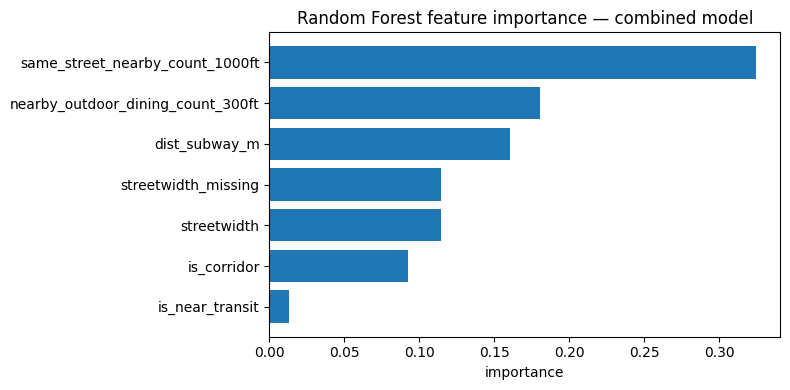

In [50]:
importance_plot_df = importance_df.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance_plot_df['feature'], importance_plot_df['importance'])
plt.title('Random Forest feature importance — combined model')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

The strongest feature was `same_street_nearby_count_1000ft`.

This means nearby repetition on the same street helped the model separate remained and disappeared locations.

It does not mean repetition caused survival.

## Results Interpretation

The combined model performed best.

It had a balanced accuracy of 0.722 and survived class recall of 0.625.

This means it found about 63% of the remained locations in the test set.

But precision was low at 0.192, so the model also made many false positive predictions.

The main signal was `same_street_nearby_count_1000ft`.

So the result is limited but useful: remained locations are partly distinguishable through local same street repetition.

## What I Tried

I started with local context features like transit distance, street width, and corridor membership.

I also tested spatial repetition features separately.

The first same street feature was too broad because long avenues could inflate the count. I replaced it with `same_street_nearby_count_1000ft`, which only counts nearby same street locations.

This made the model more conservative and easier to explain.

## What This Model Does Not Prove

This model does not explain why a specific restaurant stayed or disappeared.

It does not include permit cost, storage, seasonal decisions, enforcement, revenue, ownership decisions, or exact sidewalk setup constraints.

It only tests whether remained and disappeared locations are distinguishable with the features I had.

## Limitations

This is an exploratory classification model, not a causal model.

Some important factors are missing from the dataset.

The 1000 foot threshold is a design choice. A future version could test 500 feet, 1000 feet, and 1500 feet.

Street width was only matched for 52.5% of locations, so I used imputation and a missingness indicator.

The model also produced many false positives, so it should not be used to predict individual restaurant outcomes.

## Conclusion

The model does not explain why specific restaurants stayed.

But it does show that remained and disappeared locations are partly distinguishable.

The combined model performed best, with balanced accuracy of 0.722 and survived class recall of 0.625.

The strongest signal came from nearby repetition on the same street.

So the ML result supports the larger project finding: outdoor dining did not remain evenly across Manhattan. What remains has a measurable street level pattern.